# Logistic Regression Credit Risk Baseline

## Objective

Build a reproducible logistic-regression baseline with a strict model-train/validation/test workflow. Preprocessing and model fitting use only model-training data; model comparison and provisional threshold selection use validation data; the test set is used once for final reporting.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay, accuracy_score,
    average_precision_score, brier_score_loss, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 150)

In [2]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.feature_engineering import INITIAL_FEATURES, create_domain_features

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
TRAIN_PATH = RAW_DATA_DIR / "application_train.csv"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_PATH.exists():
    raise FileNotFoundError("Run from notebooks/ and place application_train.csv in data/raw.")
print("Training data exists:", TRAIN_PATH.exists())

Training data exists: True


## 2. Train/Validation/Test Split

In [3]:
df = pd.read_csv(TRAIN_PATH)
X = df.drop(columns=["TARGET"])
y = df["TARGET"].astype("int8")

X_development, X_test, y_development, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_model_train, X_validation, y_model_train, y_validation = train_test_split(
    X_development, y_development, test_size=0.20,
    random_state=42, stratify=y_development
)

split_summary = pd.DataFrame({
    "split": ["Model Train", "Validation", "Test"],
    "rows": [len(X_model_train), len(X_validation), len(X_test)],
    "target_rate": [y_model_train.mean(), y_validation.mean(), y_test.mean()],
})
split_summary.round(4)

,split,rows,target_rate
0,Model Train,196806,0.0807
1,Validation,49202,0.0807
2,Test,61503,0.0807


In [4]:
assert len(X_model_train) + len(X_validation) + len(X_test) == len(df)
assert set(X_model_train.index).isdisjoint(X_validation.index)
assert set(X_model_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)

## 3. Shared Feature Engineering

In [5]:
def prepare_feature_frame(raw_features):
    ids = raw_features["SK_ID_CURR"].copy()
    data = raw_features.drop(columns=["SK_ID_CURR"])
    missing = [c for c in INITIAL_FEATURES if c not in data.columns]
    if missing:
        raise ValueError(f"Missing initial features: {missing}")
    data = create_domain_features(data[INITIAL_FEATURES].copy())
    return ids, data

model_train_ids, X_model_train_fe = prepare_feature_frame(X_model_train)
validation_ids, X_validation_fe = prepare_feature_frame(X_validation)
test_ids, X_test_fe = prepare_feature_frame(X_test)

assert list(X_model_train_fe.columns) == list(X_validation_fe.columns) == list(X_test_fe.columns)
print(X_model_train_fe.shape, X_validation_fe.shape, X_test_fe.shape)

(196806, 51) (49202, 51) (61503, 51)


## 4. Full Preprocessor

In [6]:
categorical_features = X_model_train_fe.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
numerical_features = X_model_train_fe.select_dtypes(include=["number"]).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
full_preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop", verbose_feature_names_out=True)

X_model_train_processed = full_preprocessor.fit_transform(X_model_train_fe)
X_validation_processed = full_preprocessor.transform(X_validation_fe)
X_test_processed = full_preprocessor.transform(X_test_fe)
print(X_model_train_processed.shape, X_validation_processed.shape, X_test_processed.shape)

(196806, 178) (49202, 178) (61503, 178)


## 5. Full Logistic Regression Models

In [7]:
unweighted_model = LogisticRegression(
    C=1.0, solver="liblinear", max_iter=1000, random_state=42
)
balanced_model = LogisticRegression(
    C=1.0, solver="liblinear", class_weight="balanced",
    max_iter=1000, random_state=42
)
unweighted_model.fit(X_model_train_processed, y_model_train);
balanced_model.fit(X_model_train_processed, y_model_train);

In [8]:
def positive_probability(model, X):
    return model.predict_proba(X)[:, 1]

unweighted_validation_probability = positive_probability(unweighted_model, X_validation_processed)
balanced_validation_probability = positive_probability(balanced_model, X_validation_processed)
unweighted_test_probability = positive_probability(unweighted_model, X_test_processed)
balanced_test_probability = positive_probability(balanced_model, X_test_processed)

## 6. Evaluation Helpers

In [9]:
def calculate_ks(y_true, probabilities):
    fpr, tpr, thresholds = roc_curve(y_true, probabilities)
    ks = tpr - fpr
    i = int(np.argmax(ks))
    return {"ks_statistic": ks[i], "ks_threshold": thresholds[i],
            "true_positive_rate": tpr[i], "false_positive_rate": fpr[i]}

def probability_metrics(y_true, probabilities):
    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "ks_statistic": calculate_ks(y_true, probabilities)["ks_statistic"],
        "brier_score": brier_score_loss(y_true, probabilities),
        "mean_predicted_score": probabilities.mean(),
        "observed_default_rate": y_true.mean(),
    }

def evaluate_thresholds(y_true, probabilities, thresholds):
    rows=[]
    for threshold in thresholds:
        pred=(probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "accuracy": accuracy_score(y_true, pred),
            "false_positive_rate": fp/(fp+tn),
            "predicted_high_risk_rate": pred.mean(),
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp,
        })
    return pd.DataFrame(rows)

## 7. Validation Model Comparison and Threshold Selection

In [10]:
validation_model_comparison = pd.DataFrame([
    {"Model": "Unweighted Logistic Regression",
     **probability_metrics(y_validation, unweighted_validation_probability)},
    {"Model": "Balanced Logistic Regression",
     **probability_metrics(y_validation, balanced_validation_probability)},
])
validation_model_comparison.round(4)

,Model,roc_auc,pr_auc,ks_statistic,brier_score,mean_predicted_score,observed_default_rate
0,Unweighted Logistic Regression,0.7466,0.2259,0.3642,0.0687,0.0816,0.0807
1,Balanced Logistic Regression,0.7466,0.2249,0.3645,0.2047,0.4222,0.0807


In [11]:
validation_threshold_results = evaluate_thresholds(
    y_validation, balanced_validation_probability,
    np.arange(0.05, 0.96, 0.01).tolist()
)
best_f1_validation_row = validation_threshold_results.sort_values(
    "f1", ascending=False
).iloc[0]
HIGH_RISK_THRESHOLD = float(best_f1_validation_row["threshold"])
LOW_RISK_THRESHOLD = float(np.quantile(balanced_validation_probability, 0.40))
print("Low-risk cutoff:", round(LOW_RISK_THRESHOLD, 4))
print("High-risk cutoff:", round(HIGH_RISK_THRESHOLD, 4))
best_f1_validation_row.round(4)

Low-risk cutoff: 0.341
High-risk cutoff: 0.64


threshold                       0.6400
precision                       0.2144
recall                          0.4595
f1                              0.2924
accuracy                        0.8204
false_positive_rate             0.1479
predicted_high_risk_rate        0.1730
true_negatives              38542.0000
false_positives              6688.0000
false_negatives              2147.0000
true_positives               1825.0000
Name: 59, dtype: float64

The high-risk cutoff maximizes F1 on validation data. The low-risk cutoff is a provisional capacity assumption placing about 40% of validation applicants in the low-score segment. Neither cutoff is a final lending-policy decision.

## 8. Locked Final Test Evaluation

In [12]:
final_test_comparison = pd.DataFrame([
    {"Model": "Unweighted Logistic Regression",
     **probability_metrics(y_test, unweighted_test_probability)},
    {"Model": "Balanced Logistic Regression",
     **probability_metrics(y_test, balanced_test_probability)},
])
final_test_comparison.round(4)

,Model,roc_auc,pr_auc,ks_statistic,brier_score,mean_predicted_score,observed_default_rate
0,Unweighted Logistic Regression,0.7495,0.2367,0.3710,0.0682,0.0806,0.0807
1,Balanced Logistic Regression,0.7494,0.2347,0.3709,0.2024,0.4204,0.0807


In [13]:
balanced_test_prediction = (balanced_test_probability >= HIGH_RISK_THRESHOLD).astype(int)
print(classification_report(y_test, balanced_test_prediction, digits=4))
pd.DataFrame(
    confusion_matrix(y_test, balanced_test_prediction),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

              precision    recall  f1-score   support

           0     0.9479    0.8579    0.9006     56538
           1     0.2223    0.4626    0.3003      4965

    accuracy                         0.8260     61503
   macro avg     0.5851    0.6603    0.6005     61503
weighted avg     0.8893    0.8260    0.8522     61503



,Predicted 0,Predicted 1
Actual 0,48503,8035
Actual 1,2668,2297


## 9. Ranking Curves

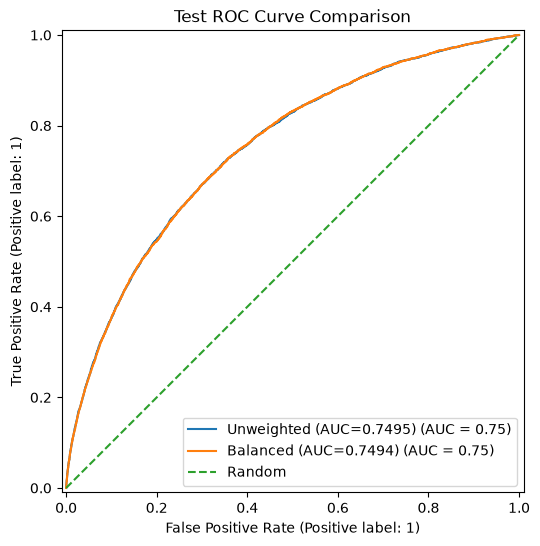

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, unweighted_test_probability,
    name=f"Unweighted (AUC={roc_auc_score(y_test, unweighted_test_probability):.4f})", ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, balanced_test_probability,
    name=f"Balanced (AUC={roc_auc_score(y_test, balanced_test_probability):.4f})", ax=ax
)
ax.plot([0,1],[0,1], linestyle="--", label="Random")
ax.set_title("Test ROC Curve Comparison")
ax.legend(); plt.show()

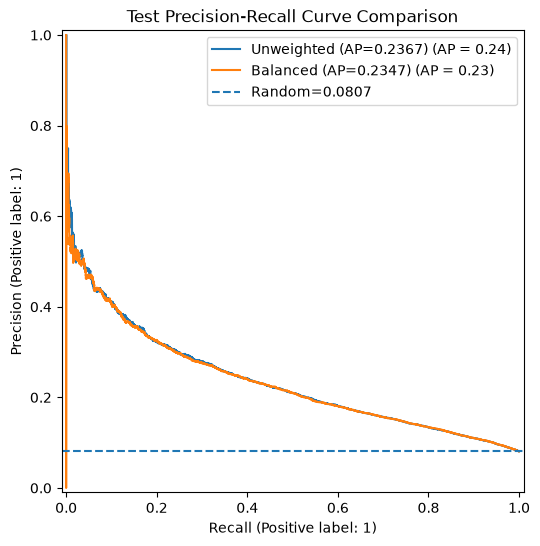

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, unweighted_test_probability,
    name=f"Unweighted (AP={average_precision_score(y_test, unweighted_test_probability):.4f})", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_test, balanced_test_probability,
    name=f"Balanced (AP={average_precision_score(y_test, balanced_test_probability):.4f})", ax=ax
)
ax.axhline(y=y_test.mean(), linestyle="--", label=f"Random={y_test.mean():.4f}")
ax.set_title("Test Precision-Recall Curve Comparison")
ax.legend(); plt.show()

## 10. Calibration

In [16]:
calibration_summary = pd.DataFrame({
    "Model": ["Unweighted Logistic Regression", "Balanced Logistic Regression"],
    "Mean Predicted Score": [unweighted_test_probability.mean(), balanced_test_probability.mean()],
    "Observed Default Rate": [y_test.mean(), y_test.mean()],
    "Brier Score": [
        brier_score_loss(y_test, unweighted_test_probability),
        brier_score_loss(y_test, balanced_test_probability),
    ],
})
calibration_summary.round(4)

,Model,Mean Predicted Score,Observed Default Rate,Brier Score
0,Unweighted Logistic Regression,0.0806,0.0807,0.0682
1,Balanced Logistic Regression,0.4204,0.0807,0.2024


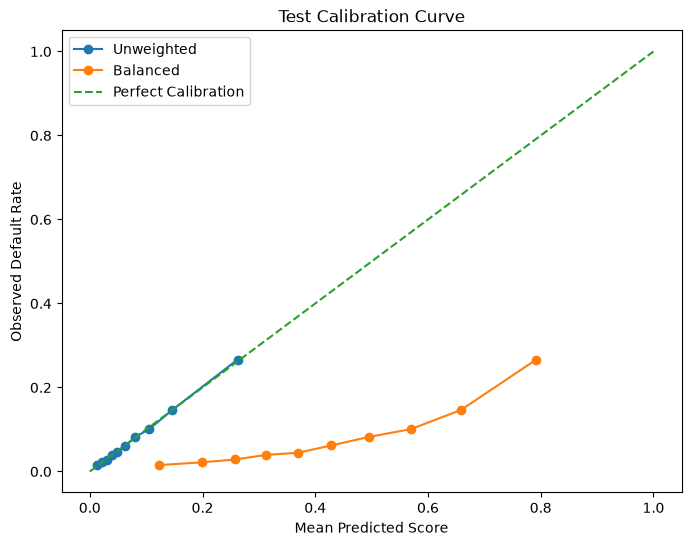

In [17]:
u_frac, u_mean = calibration_curve(
    y_test, unweighted_test_probability, n_bins=10, strategy="quantile"
)
b_frac, b_mean = calibration_curve(
    y_test, balanced_test_probability, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(8,6))
plt.plot(u_mean, u_frac, marker="o", label="Unweighted")
plt.plot(b_mean, b_frac, marker="o", label="Balanced")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Score"); plt.ylabel("Observed Default Rate")
plt.title("Test Calibration Curve"); plt.legend(); plt.show()

## 11. Validation-Selected Relative Risk Bands

In [18]:
def assign_risk_band(score):
    if score < LOW_RISK_THRESHOLD:
        return "Low Risk"
    if score < HIGH_RISK_THRESHOLD:
        return "Medium Risk"
    return "High Risk"

test_risk_results = pd.DataFrame({
    "SK_ID_CURR": test_ids.reset_index(drop=True),
    "TARGET": y_test.reset_index(drop=True),
    "MODEL_SCORE": balanced_test_probability,
})
test_risk_results["RISK_BAND"] = test_risk_results["MODEL_SCORE"].apply(assign_risk_band)
test_risk_band_summary = test_risk_results.groupby("RISK_BAND").agg(
    applicants=("SK_ID_CURR", "count"),
    observed_default_rate=("TARGET", "mean"),
    average_model_score=("MODEL_SCORE", "mean"),
)
test_risk_band_summary["portfolio_share"] = (
    test_risk_band_summary["applicants"] / len(test_risk_results)
)
test_risk_band_summary.round(4)

,applicants,observed_default_rate,average_model_score,portfolio_share
RISK_BAND,,,,
High Risk,10332,0.2223,0.7440,0.1680
Low Risk,24679,0.0263,0.2233,0.4013
Medium Risk,26492,0.0762,0.4778,0.4307


Balanced-model values are relative model scores, not calibrated probabilities of default. The bands do not represent automatic approve/decline decisions.

## 12. Reduced Interpretable Model

In [19]:
INTERPRETABLE_NUMERICAL_FEATURES = [
    "CNT_CHILDREN", "CNT_FAM_MEMBERS", "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY", "AGE_YEARS",
    "EMPLOYMENT_YEARS", "REGISTRATION_YEARS", "ID_PUBLISH_YEARS",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "GOODS_CREDIT_RATIO",
    "EMPLOYMENT_AGE_RATIO", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "EXT_SOURCE_MISSING_COUNT", "BUREAU_INQUIRY_TOTAL",
    "DAYS_EMPLOYED_SPECIAL_FLAG", "TOTAL_MISSING_COUNT",
]
INTERPRETABLE_CATEGORICAL_FEATURES = [
    "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE",
]
interpretable_features = INTERPRETABLE_NUMERICAL_FEATURES + INTERPRETABLE_CATEGORICAL_FEATURES

In [20]:
X_mt_i = X_model_train_fe[interpretable_features].copy()
X_val_i = X_validation_fe[interpretable_features].copy()
X_test_i = X_test_fe[interpretable_features].copy()

i_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
i_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True)),
])
interpretable_preprocessor = ColumnTransformer([
    ("numerical", i_num, INTERPRETABLE_NUMERICAL_FEATURES),
    ("categorical", i_cat, INTERPRETABLE_CATEGORICAL_FEATURES),
], remainder="drop", verbose_feature_names_out=True)

X_mt_i_p = interpretable_preprocessor.fit_transform(X_mt_i)
X_val_i_p = interpretable_preprocessor.transform(X_val_i)
X_test_i_p = interpretable_preprocessor.transform(X_test_i)
interpretable_model = LogisticRegression(
    C=1.0, solver="liblinear", max_iter=1000, random_state=42
)
interpretable_model.fit(X_mt_i_p, y_model_train);

In [21]:
interpretable_validation_probability = positive_probability(interpretable_model, X_val_i_p)
interpretable_test_probability = positive_probability(interpretable_model, X_test_i_p)
full_vs_interpretable_comparison = pd.DataFrame([
    {"Model": "Full Unweighted Baseline",
     "Validation ROC-AUC": roc_auc_score(y_validation, unweighted_validation_probability),
     "Test ROC-AUC": roc_auc_score(y_test, unweighted_test_probability),
     "Test PR-AUC": average_precision_score(y_test, unweighted_test_probability),
     "Test KS": calculate_ks(y_test, unweighted_test_probability)["ks_statistic"],
     "Test Brier Score": brier_score_loss(y_test, unweighted_test_probability)},
    {"Model": "Reduced Interpretable Model",
     "Validation ROC-AUC": roc_auc_score(y_validation, interpretable_validation_probability),
     "Test ROC-AUC": roc_auc_score(y_test, interpretable_test_probability),
     "Test PR-AUC": average_precision_score(y_test, interpretable_test_probability),
     "Test KS": calculate_ks(y_test, interpretable_test_probability)["ks_statistic"],
     "Test Brier Score": brier_score_loss(y_test, interpretable_test_probability)},
])
full_vs_interpretable_comparison.round(4)

,Model,Validation ROC-AUC,Test ROC-AUC,Test PR-AUC,Test KS,Test Brier Score
0,Full Unweighted Baseline,0.7466,0.7495,0.2367,0.3710,0.0682
1,Reduced Interpretable Model,0.7415,0.7455,0.2309,0.3645,0.0685


## 13. Coefficients and Stable Categories

In [22]:
feature_names = [
    n.replace("numerical__", "").replace("categorical__", "")
    for n in interpretable_preprocessor.get_feature_names_out()
]
interpretable_coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": interpretable_model.coef_[0],
})
interpretable_coefficient_table["absolute_coefficient"] = interpretable_coefficient_table["coefficient"].abs()
interpretable_coefficient_table["odds_ratio"] = np.exp(interpretable_coefficient_table["coefficient"])
interpretable_coefficient_table = interpretable_coefficient_table.sort_values(
    "absolute_coefficient", ascending=False
)
interpretable_coefficient_table.head(25).round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
118,ORGANIZATION_TYPE_Trade: type 5,-0.9524,0.9524,0.3858
117,ORGANIZATION_TYPE_Trade: type 4,-0.8503,0.8503,0.4273
34,NAME_INCOME_TYPE_Pensioner,-0.8204,0.8204,0.4403
105,ORGANIZATION_TYPE_Realtor,0.7724,0.7724,2.1649
36,NAME_INCOME_TYPE_Student,-0.6538,0.6538,0.5201
61,OCCUPATION_TYPE_Low-skill Laborers,0.5734,0.5734,1.7743
123,ORGANIZATION_TYPE_Transport: type 3,0.5300,0.5300,1.6988
100,ORGANIZATION_TYPE_Military,-0.5163,0.5163,0.5967
94,ORGANIZATION_TYPE_Industry: type 8,0.5106,0.5106,1.6663
15,EXT_SOURCE_3,-0.5054,0.5054,0.6032


In [23]:
def category_support_table(raw_data, target):
    data=raw_data.copy(); data["TARGET"] = target
    rows=[]
    for feature in INTERPRETABLE_CATEGORICAL_FEATURES:
        g=data.groupby(feature, dropna=False).agg(
            applicants=("TARGET", "size"),
            observed_default_rate=("TARGET", "mean"),
        ).reset_index().rename(columns={feature:"category"})
        g["original_feature"] = feature
        rows.append(g)
    return pd.concat(rows, ignore_index=True)

category_support = category_support_table(X_model_train_fe, y_model_train)
rows=[]
for feature in INTERPRETABLE_CATEGORICAL_FEATURES:
    matches=interpretable_coefficient_table[
        interpretable_coefficient_table["feature"].str.startswith(feature + "_")
    ]
    for _, r in matches.iterrows():
        category=r["feature"][len(feature)+1:]
        s=category_support[(category_support["original_feature"]==feature) &
                           (category_support["category"].astype(str)==str(category))]
        if not s.empty:
            rows.append({
                "encoded_feature": r["feature"], "original_feature": feature,
                "category": category, "coefficient": r["coefficient"],
                "odds_ratio": r["odds_ratio"],
                "applicants": s["applicants"].iloc[0],
                "observed_default_rate": s["observed_default_rate"].iloc[0],
            })
stable_categorical_coefficients = pd.DataFrame(rows)
stable_categorical_coefficients = stable_categorical_coefficients[
    stable_categorical_coefficients["applicants"] >= 500
].sort_values("coefficient", ascending=False)
stable_categorical_coefficients.head(20).round(4)

,encoded_feature,original_feature,category,coefficient,odds_ratio,applicants,observed_default_rate
24,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE,Low-skill Laborers,0.5734,1.7743,1369,0.1782
44,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE,Transport: type 3,0.5300,1.6988,770,0.1649
25,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE,Drivers,0.4424,1.5565,11934,0.1122
10,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE,Lower secondary,0.4371,1.5482,2410,0.1112
26,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE,Security staff,0.3529,1.4232,4309,0.1042
27,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE,Laborers,0.3130,1.3675,35367,0.1066
11,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_EDUCATION_TYPE,Secondary / secondary special,0.3026,1.3533,139789,0.0890
30,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE,Secretaries,0.2736,1.3147,824,0.0740
31,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE,Managers,0.2611,1.2984,13673,0.0625
32,OCCUPATION_TYPE_Waiters/barmen staff,OCCUPATION_TYPE,Waiters/barmen staff,0.2247,1.2519,851,0.1152


## 14. Save Artifacts and Reports

In [24]:
joblib.dump(full_preprocessor, MODEL_DIR / "logistic_full_preprocessor.joblib")
joblib.dump(unweighted_model, MODEL_DIR / "logistic_unweighted_model.joblib")
joblib.dump(balanced_model, MODEL_DIR / "logistic_balanced_model.joblib")
joblib.dump(interpretable_preprocessor, MODEL_DIR / "logistic_interpretable_preprocessor.joblib")
joblib.dump(interpretable_model, MODEL_DIR / "logistic_interpretable_model.joblib")

validation_model_comparison.to_csv(
    REPORTS_DIR / "logistic_validation_model_comparison.csv", index=False
)
final_test_comparison.to_csv(
    REPORTS_DIR / "logistic_final_test_comparison.csv", index=False
)
test_risk_band_summary.reset_index().to_csv(
    REPORTS_DIR / "logistic_provisional_risk_bands.csv", index=False
)
full_vs_interpretable_comparison.to_csv(
    REPORTS_DIR / "logistic_full_vs_interpretable.csv", index=False
)
interpretable_coefficient_table.to_csv(
    REPORTS_DIR / "logistic_interpretable_coefficients.csv", index=False
)
stable_categorical_coefficients.to_csv(
    REPORTS_DIR / "logistic_stable_categorical_coefficients.csv", index=False
)
print("Artifacts and reports saved.")

Artifacts and reports saved.


## Final Summary

- Preprocessing and model fitting use only model-training data.
- Model comparison and provisional threshold selection use validation data.
- The test set is reserved for final reporting.
- The unweighted model is the probability baseline.
- The balanced model is a high-recall screening benchmark; its scores are not calibrated PDs.
- The reduced model supports coefficient interpretation.
- Risk-band cutoffs remain provisional until business costs, review capacity, fairness, and regulatory requirements are defined.